In [6]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm

In [7]:
# Constants
lam = 1550 # [nm]

In [8]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('ABCD_fringe_tracking', verbose=True)


Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-03-19_f2ef0b2/3_ABCD_fringe_tracking


Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:15<00:46, 15.40s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:30<00:30, 15.50s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:46<00:15, 15.73s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:03<00:00, 15.76s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection max of seg=138: (tip, tilt) = (-0.81287,0.41830) mrad
Injection spread of seg=138: (tip, tilt) = (0.63298,0.80681) mrad
Injection max of seg=137: (tip, tilt) = (-0.31550,0.29687) mrad
Injection spread of seg=137: (tip, tilt) = (0.70410,0.75465) mrad
Injection max of seg=136: (tip, tilt) = (0.00919,0.11360) mrad
Injection spread of seg=136: (tip, tilt) = (0.69563,0.81450) mrad
Injection max of seg=135: (tip, tilt) = (0.21745,0.14980) mrad
Injection spread of seg=135: (tip, tilt) = (0.71256,0.84584) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.82217,0.42667) mrad; flux = 543.6
Injection max of seg=137: (tip, tilt) = (-0.32545,0.30019) mrad; flux = 632.8
Injection max of seg=136: (tip, tilt) = (0.00478,0.12181) mrad; flux = 531.7
Injection max of seg=135: (tip, tilt) =


── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 0 (seg 138), target flux = 512.3
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.6522 mrad, flux = 513.5 (target 512.3), iterations = 12
  Dichotomy on channel 2 (seg 136)…
Injection OFF on channels [0, 1, 3] (segments [138, 137, 135])
    → balanced tilt = 0.2632 mrad, flux = 507.4 (target 512.3), iterations = 12
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.5722 mrad, flux = 501.8 (target 512.3), iterations = 12
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


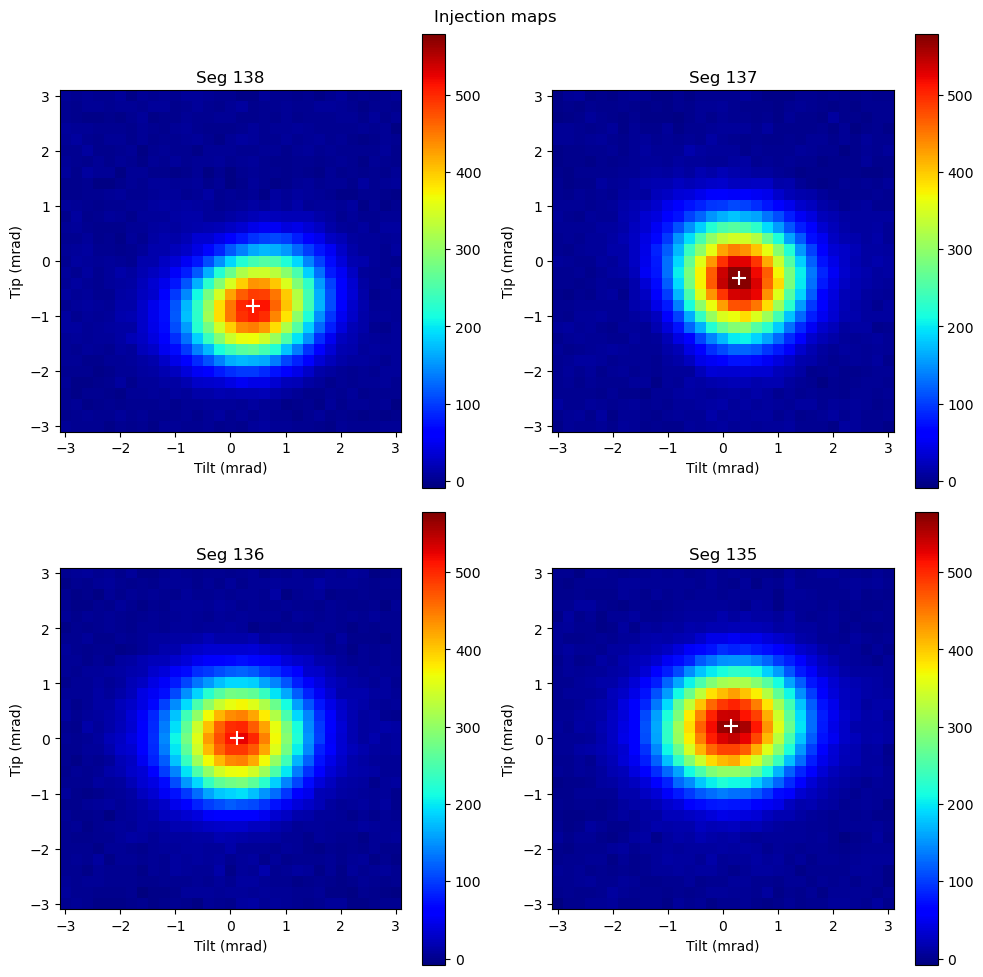

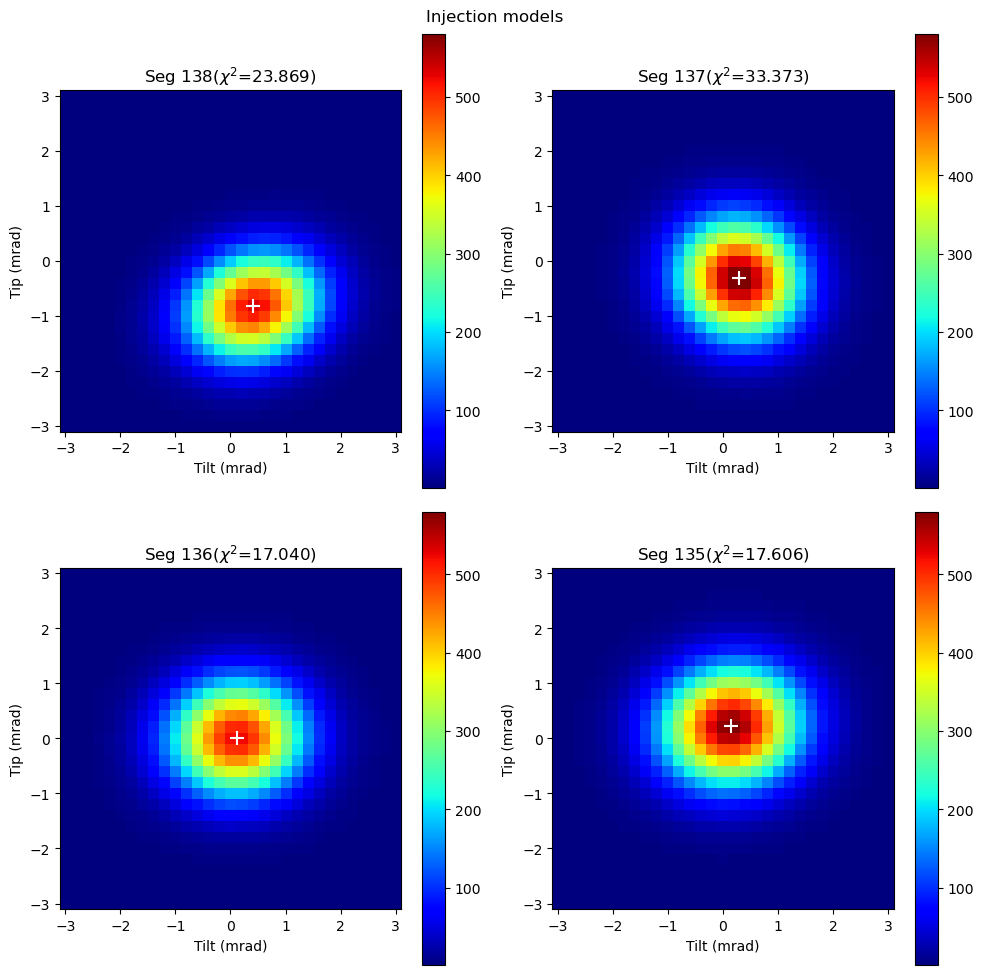

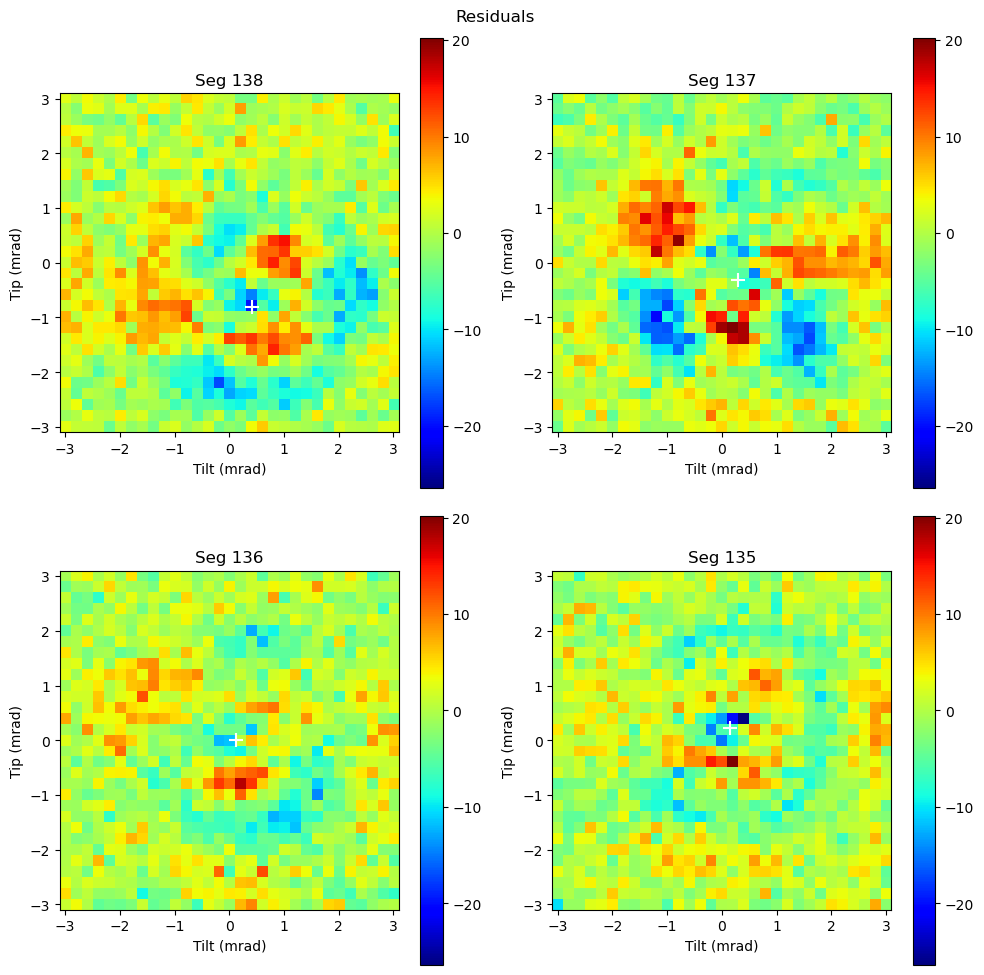

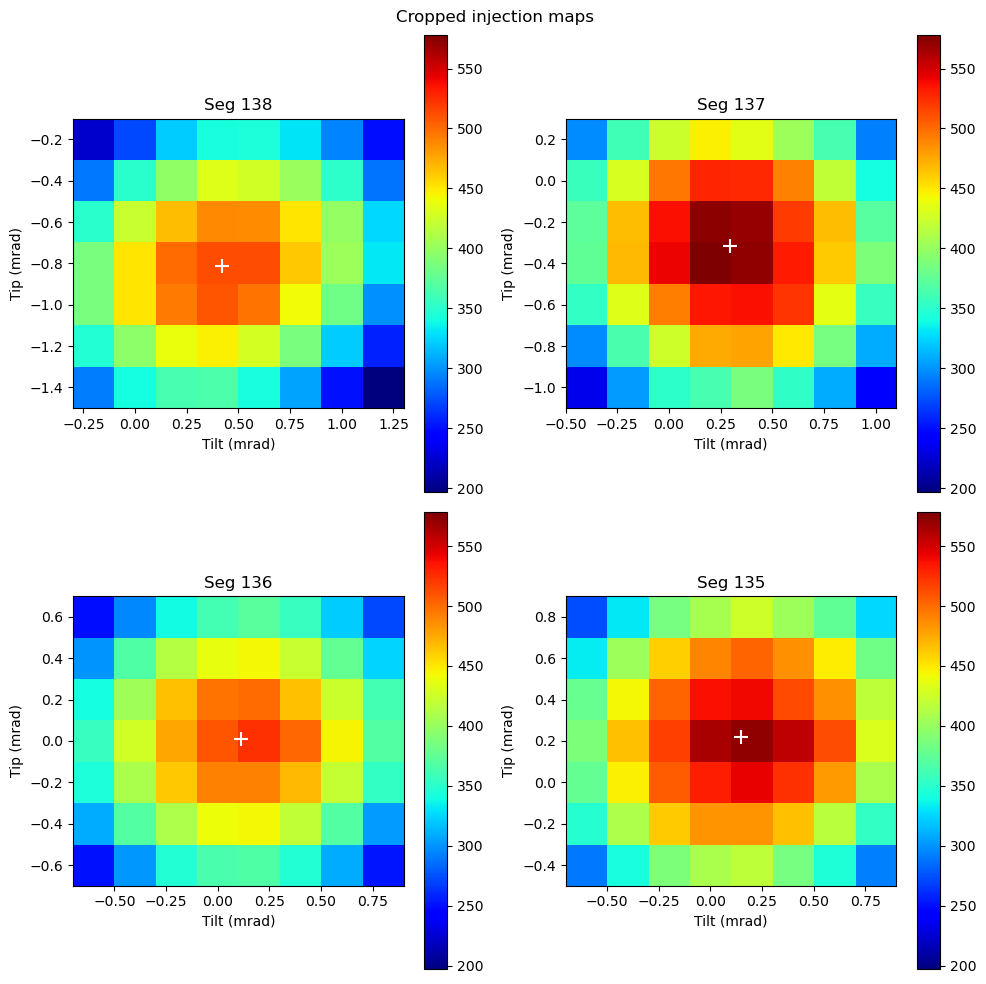

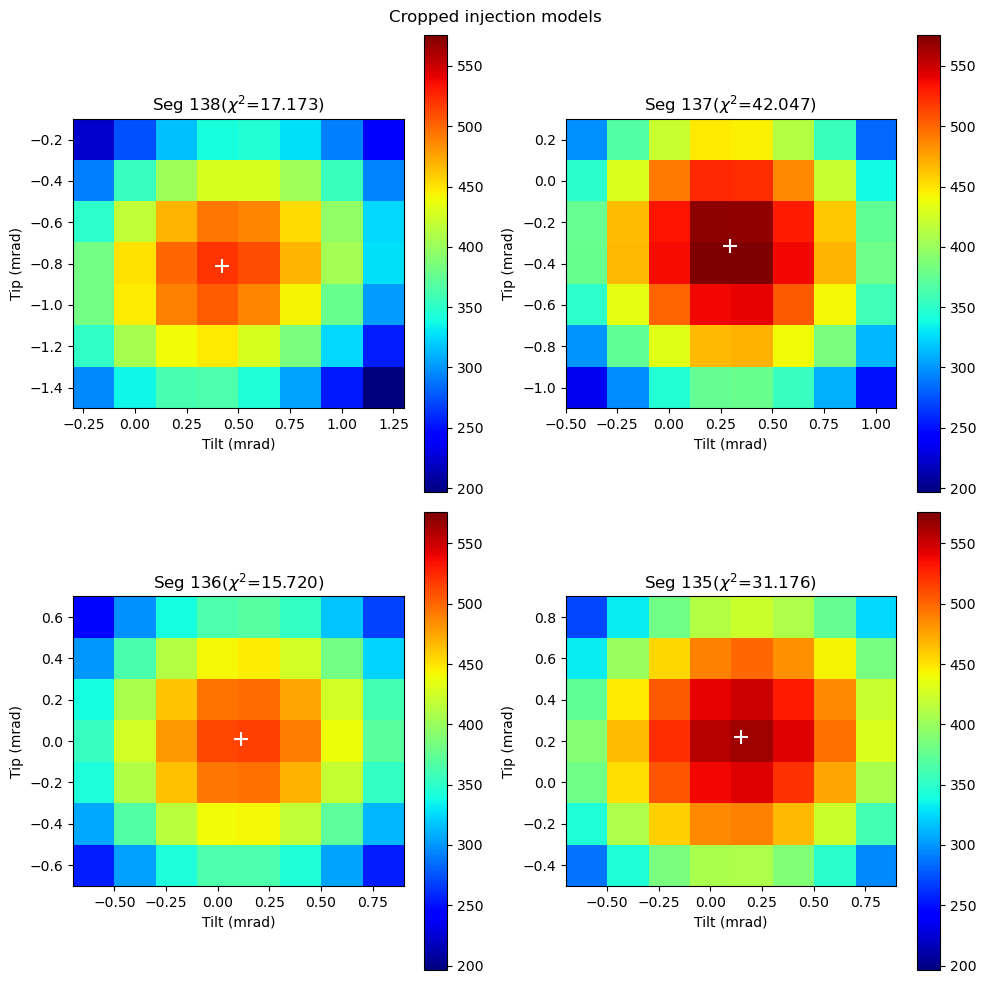

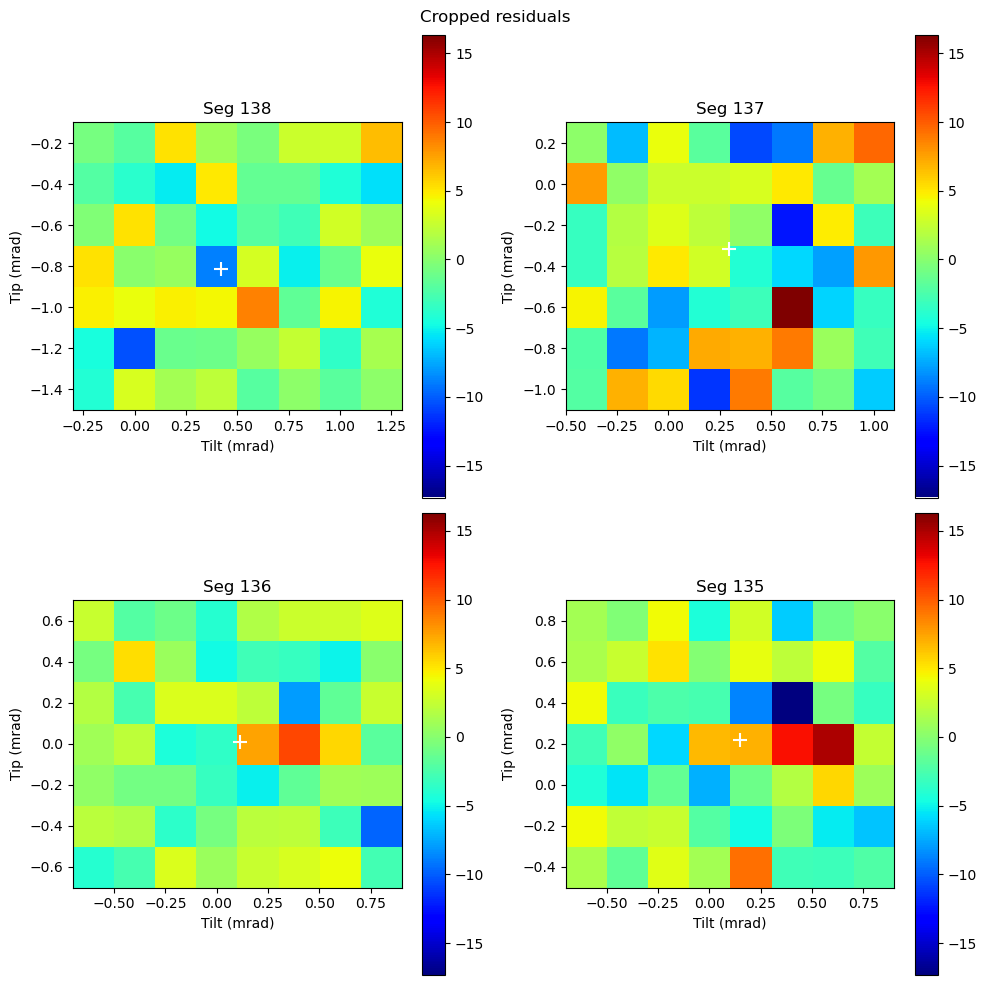

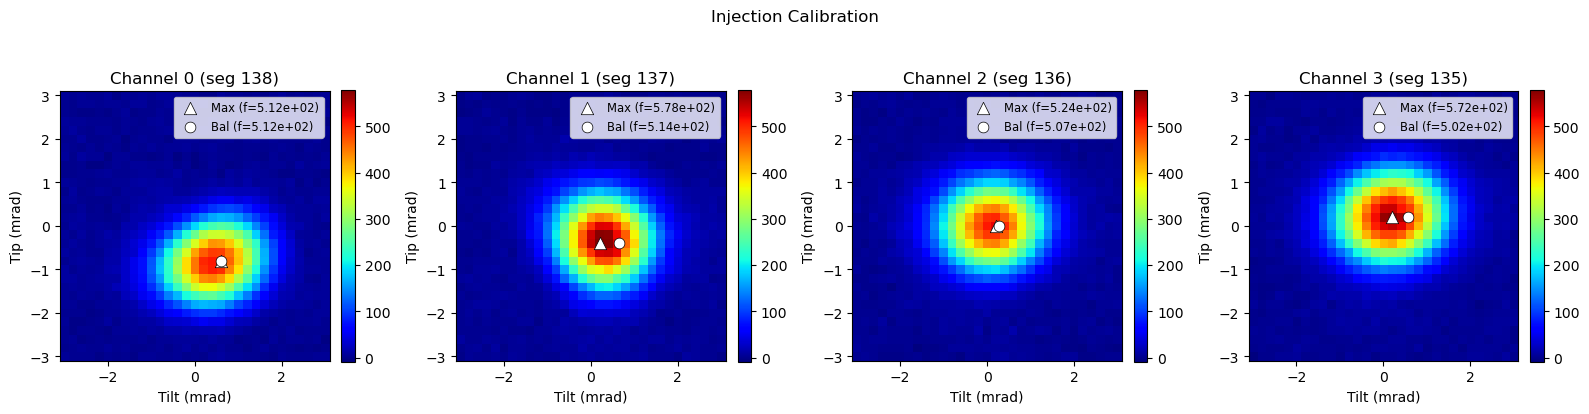

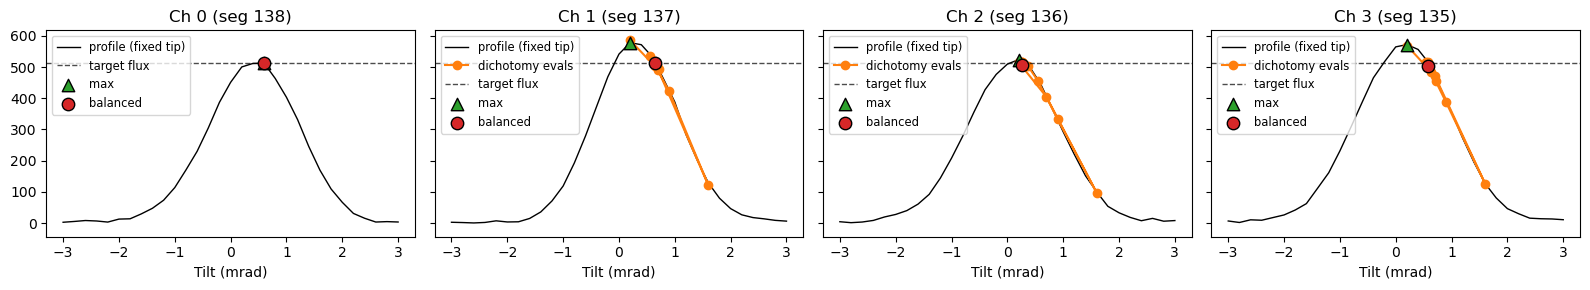

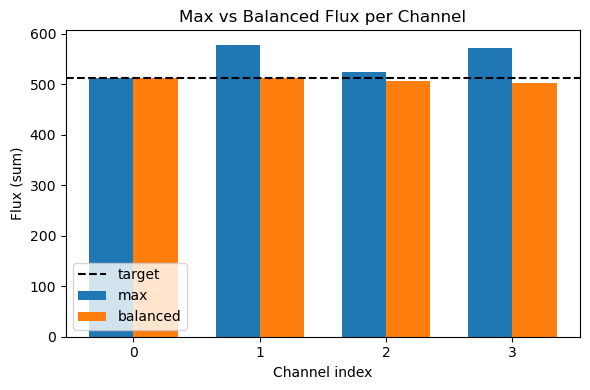

Successfully saved in FITS
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [9]:
# Injection calibration
inj = phobos.Injection()
avg_frame = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path)

inj.set_balanced()



/home/photonics/Progs/repos/PHOBos/src/phobos/classes/photonic_chip/phase_shifter.py:156: RuntimeWarning: invalid value encountered in sqrt
  voltage = np.sqrt(power / self.power_dac_factor)


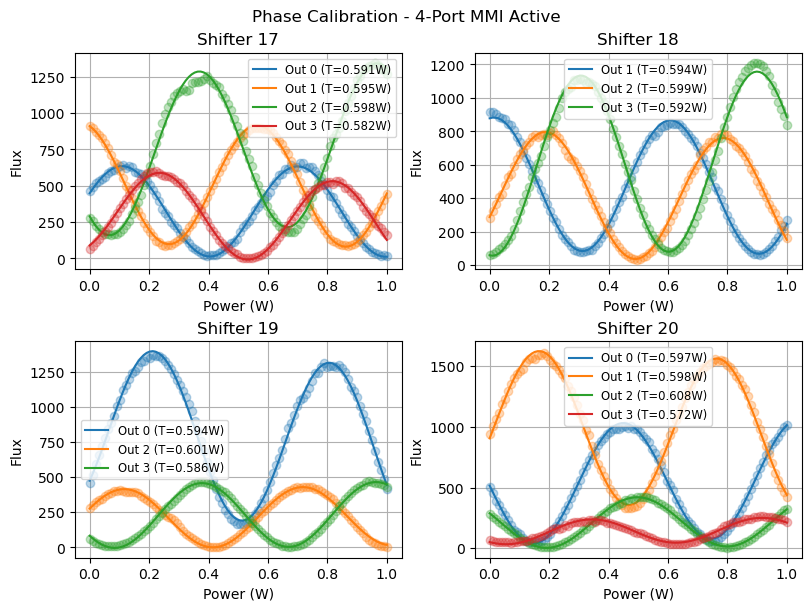

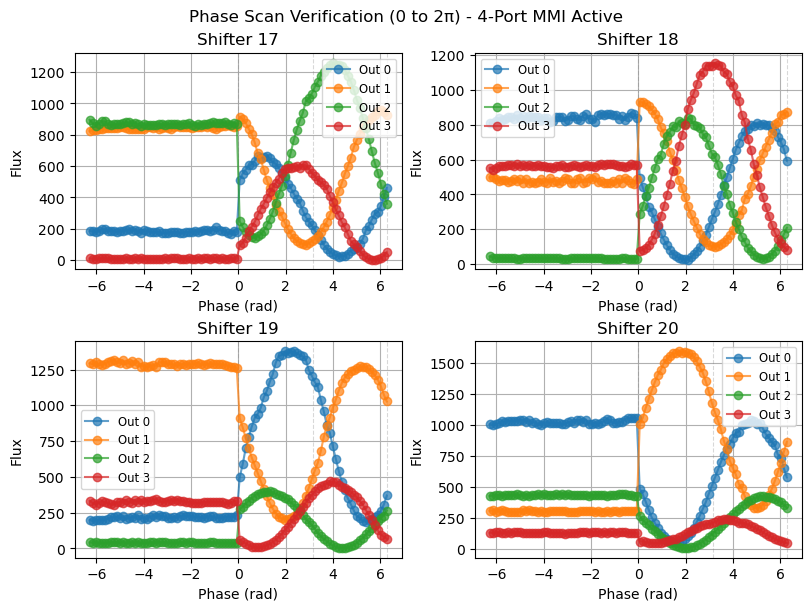

array([[[ 462.80474854,  913.94445801,  278.53979492,   65.46834564],
        [ 488.15585327,  896.79333496,  255.23756409,   86.65057373],
        [ 518.39141846,  867.59332275,  223.97979736,  110.81945801],
        ...,
        [  16.90253067,  361.33547974, 1306.50866699,  206.83721924],
        [  21.08475304,  402.52661133, 1299.75744629,  178.58389282],
        [  16.65808678,  444.96221924, 1270.45532227,  158.25054932]],

       [[ 465.12030029,  918.34887695,  283.01980591,   64.02389526],
        [ 427.07589722,  914.97998047,  323.1086731 ,   68.41056061],
        [ 394.40029907,  903.36224365,  365.7975769 ,   77.71723175],
        ...,
        [ 638.97814941,  209.42884827,  240.9753418 ,  934.56610107],
        [ 680.96923828,  232.69107056,  201.96202087,  893.57055664],
        [ 709.50701904,  273.45108032,  165.27313232,  839.77502441]],

       [[ 456.04476929,  932.97998047,  281.89978027,   57.15723038],
        [ 517.78253174,  885.20220947,  302.4420166 ,   44.6

In [10]:
# TOPAs calibration
chip.phase_calibration(plot=True, verbose=False)

# Mono-beam scan

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


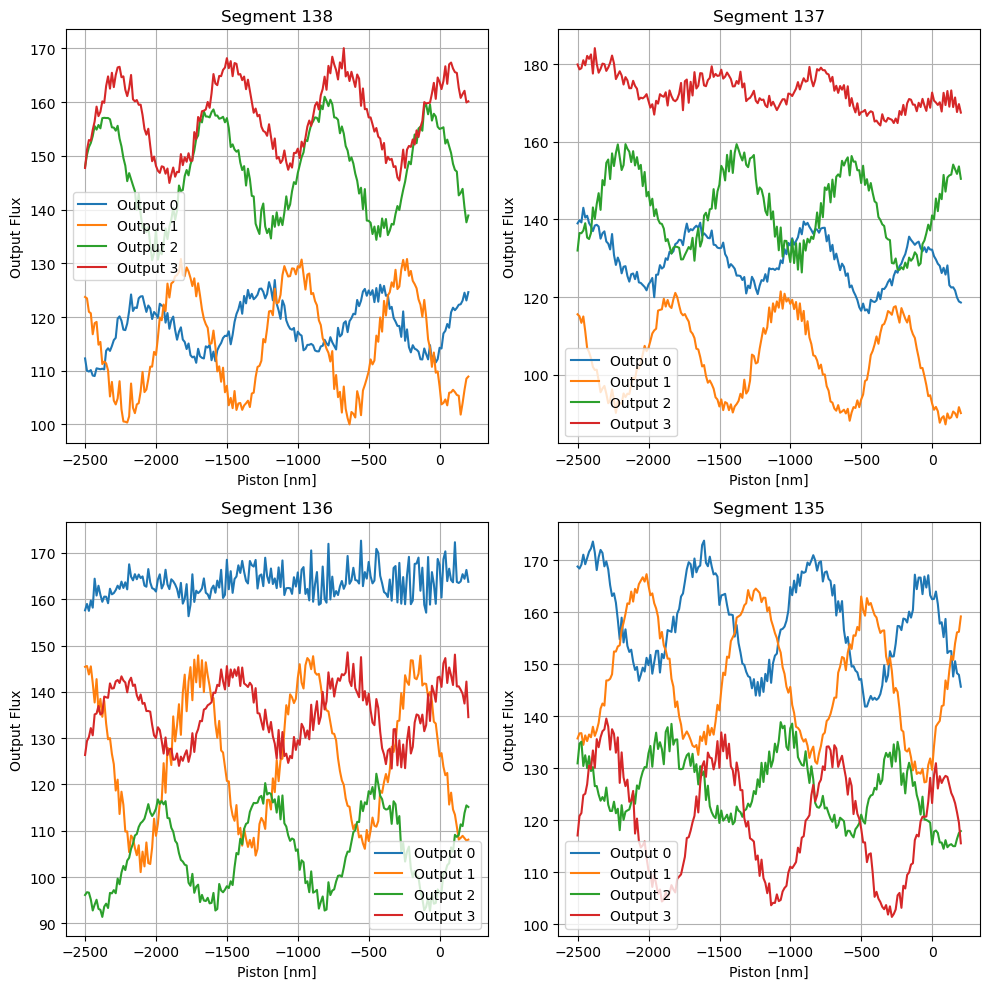

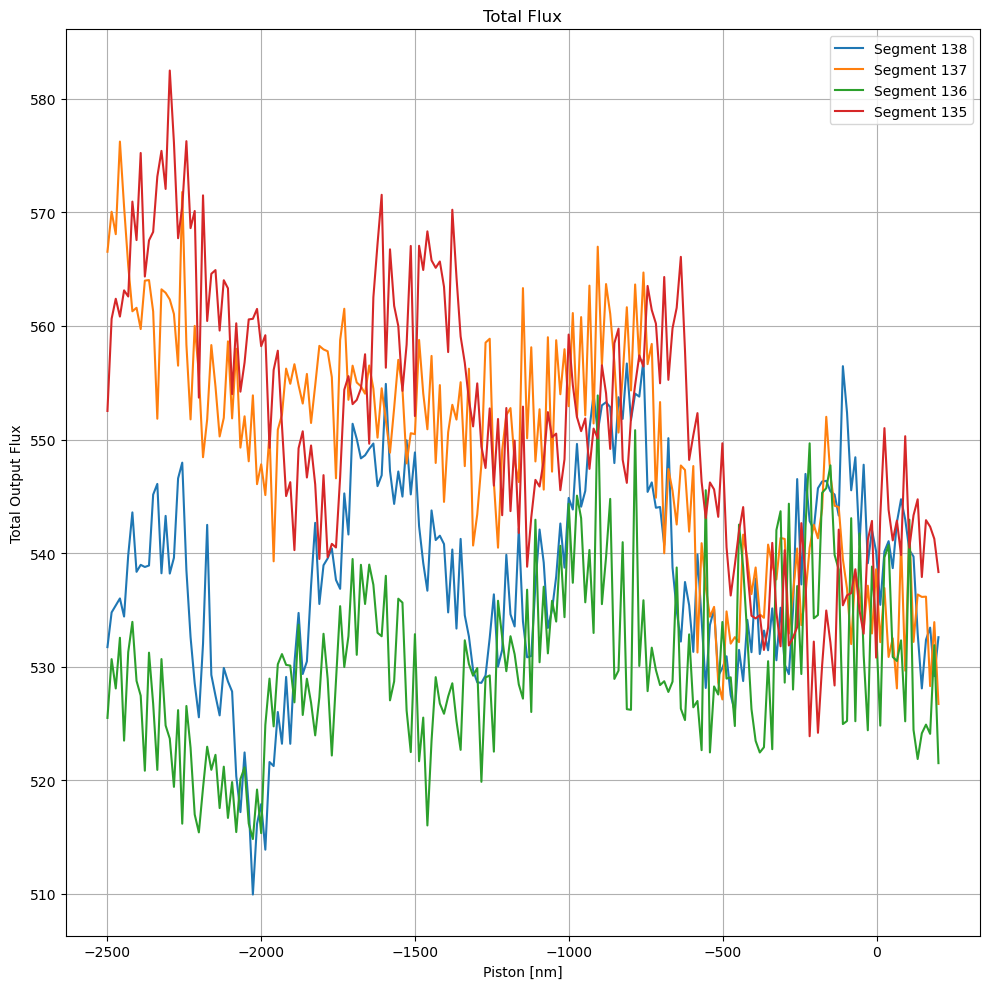

In [11]:
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_balanced(beam)

    outs = np.empty((len(piston_range), 4))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_piston(opd)
        outs[p] = cam.get_outputs(flux_mode='mean')

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(4):
        axs[beam].plot(piston_range, outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel('Piston [nm]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))

for o in range(4):
    axs.plot(piston_range, total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

axs.set_title('Total Flux')
axs.set_xlabel('Piston [nm]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_balanced_totalflux.png')

inj.set_balanced()


Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


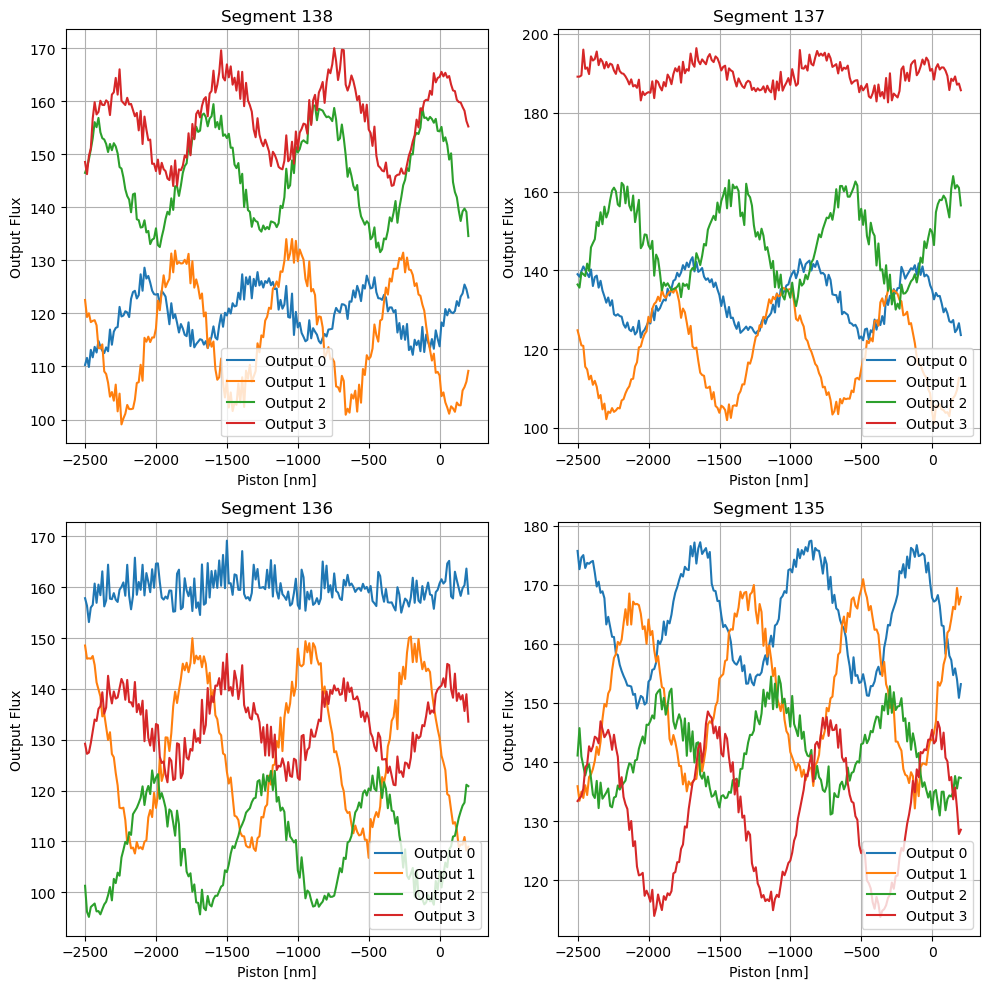

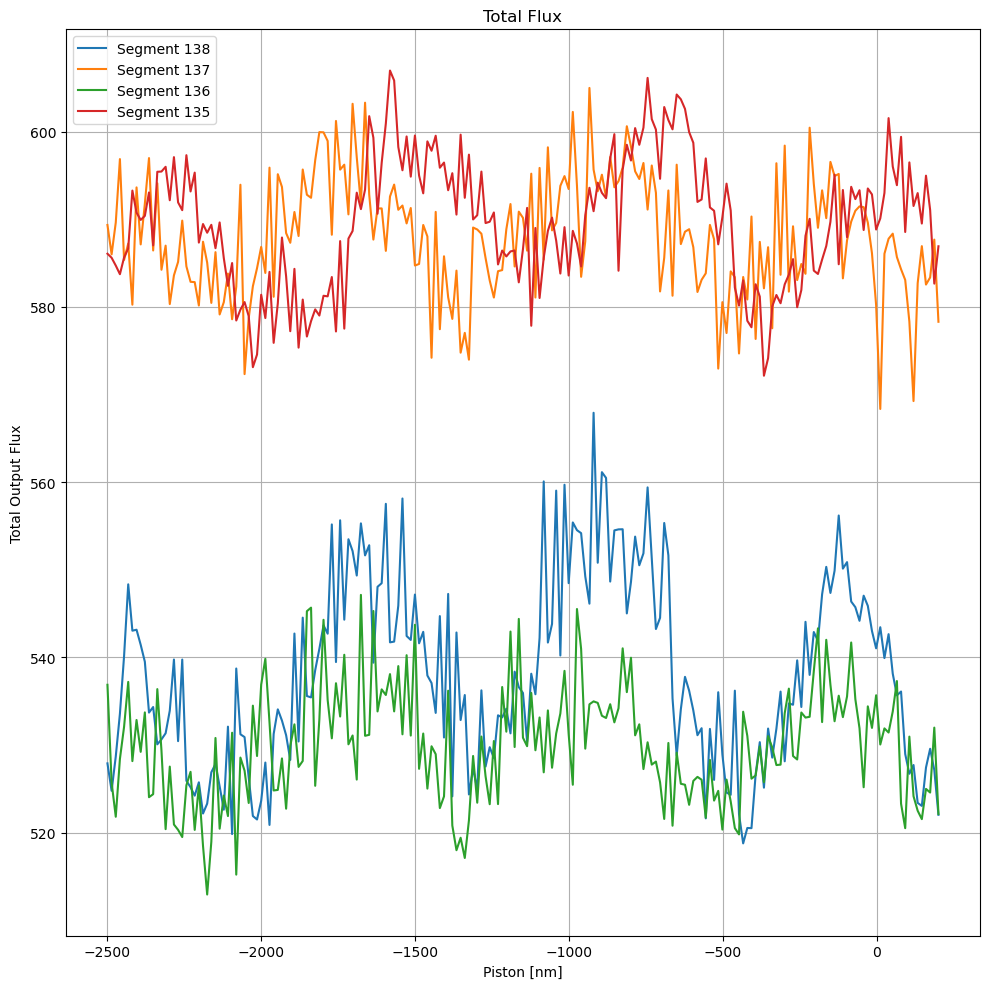

In [12]:
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_max(beam)

    outs = np.empty((len(piston_range), 4))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_piston(opd)
        outs[p] = cam.get_outputs(flux_mode='mean')

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(4):
        axs[beam].plot(piston_range, outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel('Piston [nm]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))

for o in range(4):
    axs.plot(piston_range, total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

axs.set_title('Total Flux')
axs.set_xlabel('Piston [nm]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max_totalflux.png')

inj.set_balanced()

# Pair scan

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

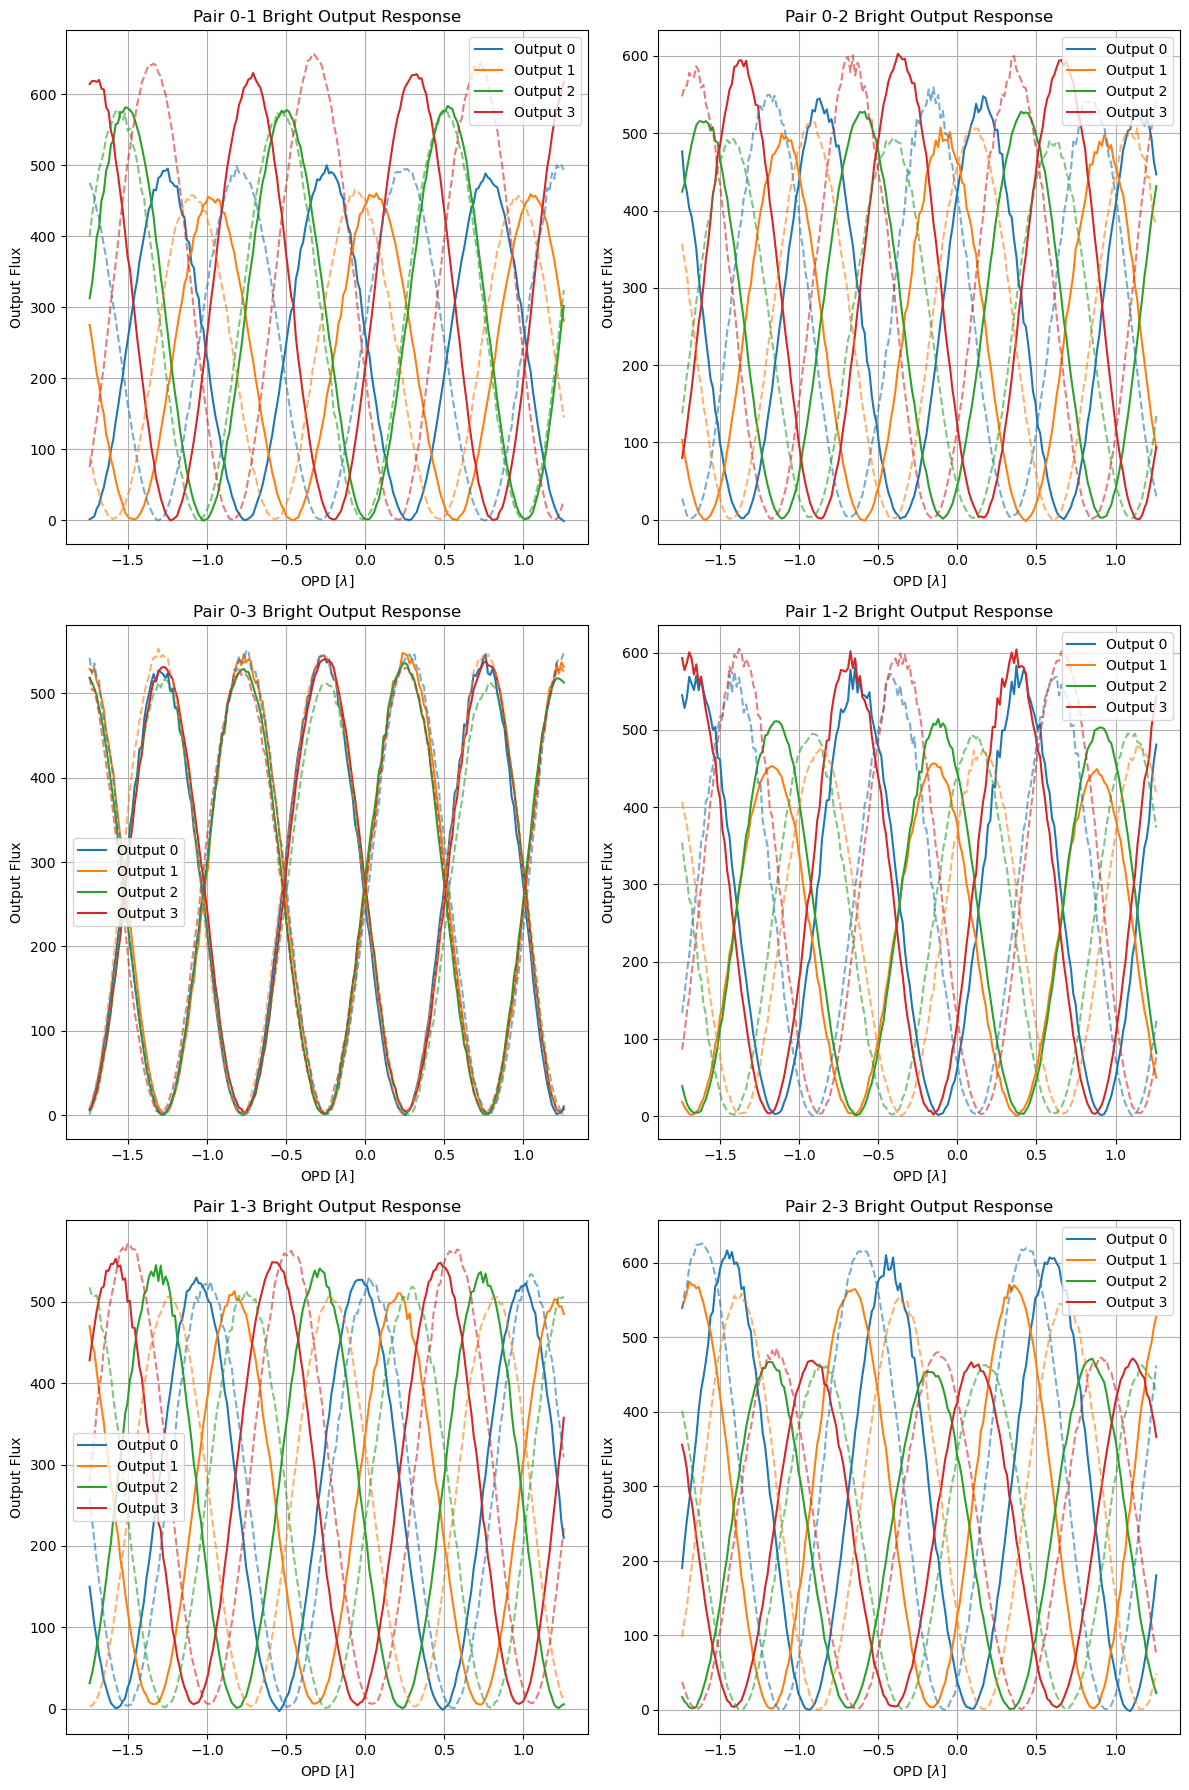

In [13]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 3.

piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_pair_scan = {}

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    dm[inj_seg[pair[1]]].set_piston(ref_cart)
    # Scan on first input
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[0]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[0], pair[1])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')

    # Scan on second input
    inj.off()
    inj.set_balanced(np.array(pair))

    dm[inj_seg[pair[0]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[1]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
    
    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
fig.savefig(path / 'pair_scan.png')

with open(path / 'pair_scan_data.pkl', 'wb') as f:
    pickle.dump(res_pair_scan, f)


inj.set_balanced()

# Piston ramp with counter phase shift

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

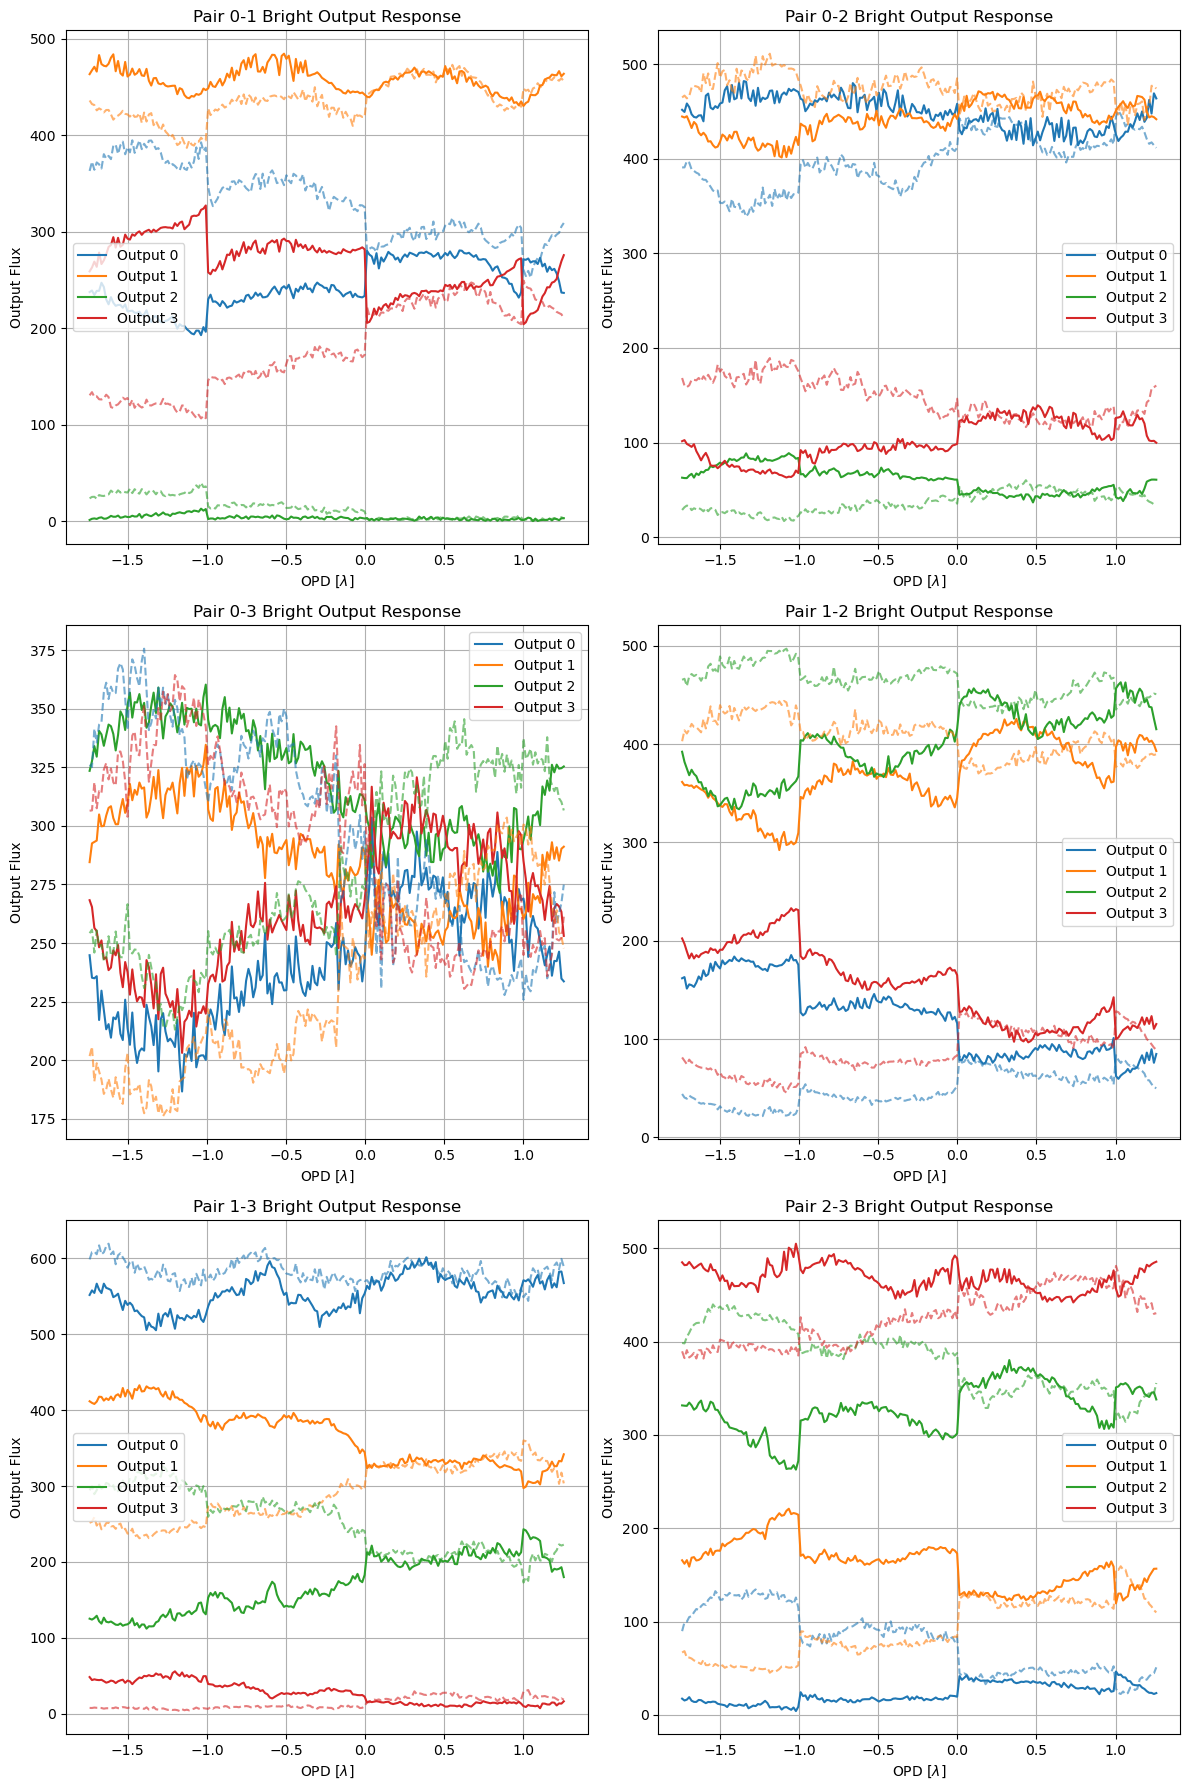

In [14]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 3.

piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_ramp_scan = {}

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    # Scan on first input
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    dm[inj_seg[pair[1]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phase = phase % (2 * np.pi)
        phases = np.zeros(4)
        phases[pair[0]] = phase
        chip.set_phases(phases)
        dm[inj_seg[pair[0]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    phases[pair[0]] = 0.
    chip.set_phases(phases)

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_ramp_scan[(pair[0], pair[1])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')

    # Scan on second input
    inj.off()
    chip.set_phases([0,0,0,0])
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[0]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2    

    dm[inj_seg[pair[0]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phase = phase % (2 * np.pi)
        phases = np.zeros(4)
        phases[pair[1]] = phase
        chip.set_phases(phases)        
        dm[inj_seg[pair[1]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    phases[pair[1]] = 0.
    chip.set_phases(phases)
    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)        

    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()
    

fig.tight_layout()
fig.savefig(path / 'ramp.png')

with open(path / 'ramp_scan_data.pkl', 'wb') as f:
    pickle.dump(res_ramp_scan, f)

inj.set_balanced()
chip.set_phases([0, 0, 0, 0])

# Upstream piston RMS regimes

In [15]:
def rms_scan(n, rms_values, wl, pair, correct_with_topas=False, plot=True):
    inj.off()
    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced(pair)
    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    print('Ref positions:', ref_cart)
    ref_tip = dm[inj_seg[pair[1]]].get_tip()
    ref_tilt = dm[inj_seg[pair[1]]].get_tilt()

    res = {}

    if plot:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Upstream Piston RMS Regimes - Pair {pair[0]}-{pair[1]}', fontsize=16)
        axs = axs.flatten()
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    else:
        fig = None

    for i, rms in enumerate(rms_values):

        print(f'Scanning RMS={rms} nm...')

        outs = np.empty((n, 4))
        res_pistons = np.empty((n, 2))
        res_phases = np.empty((n,))
        np.random.seed(0)
        for p in tqdm(range(n)):
            pistons = np.random.normal(ref_cart, rms)  # [nm]
            # dm[inj_seg[pair[0]]].set_ptt(pistons, ref_tip, ref_tilt)
            dm[inj_seg[pair[0]]].set_piston(pistons)

            opd = (pistons - ref_cart) * 2
            phase = 2 * np.pi / wl * opd
            phase = phase % (2 * np.pi)
            phases = np.zeros(4)
            phases[pair[0]] = phase
            
            if correct_with_topas:
                chip.set_phases(phases)
                
            outs[p] = cam.get_outputs(flux_mode='mean')
            res_pistons[p] = pistons
            res_phases[p] = phases[pair[0]]

        res[rms] = {'flux':outs.copy(), 'pistons': res_pistons, 'phase':res_phases}

        if plot:
            for o in range(4):
                axs[i].hist(outs[:, o], bins=20, color=colors[o], alpha=0.7, label='Output %s (%.2f ± %.2f)'%(o, outs[:, o].mean(), outs[:, o].std()))
            axs[i].set_title(f'RMS {rms} nm Output Distribution')
            axs[i].set_xlabel('Output Flux')
            axs[i].set_ylabel('Counts')
            axs[i].legend()
            axs[i].grid()

    if plot:
        fig.tight_layout()

    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced()        

    return {'data': res, 'figure': fig}

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=5 nm...


100%|██████████| 1000/1000 [00:14<00:00, 70.35it/s]


Scanning RMS=10 nm...


100%|██████████| 1000/1000 [00:14<00:00, 70.54it/s]


Scanning RMS=50 nm...


...

Scanning RMS=100 nm...


100%|██████████| 1000/1000 [00:14<00:00, 70.00it/s]


Scanning RMS=200 nm...


100%|██████████| 1000/1000 [00:14<00:00, 69.23it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


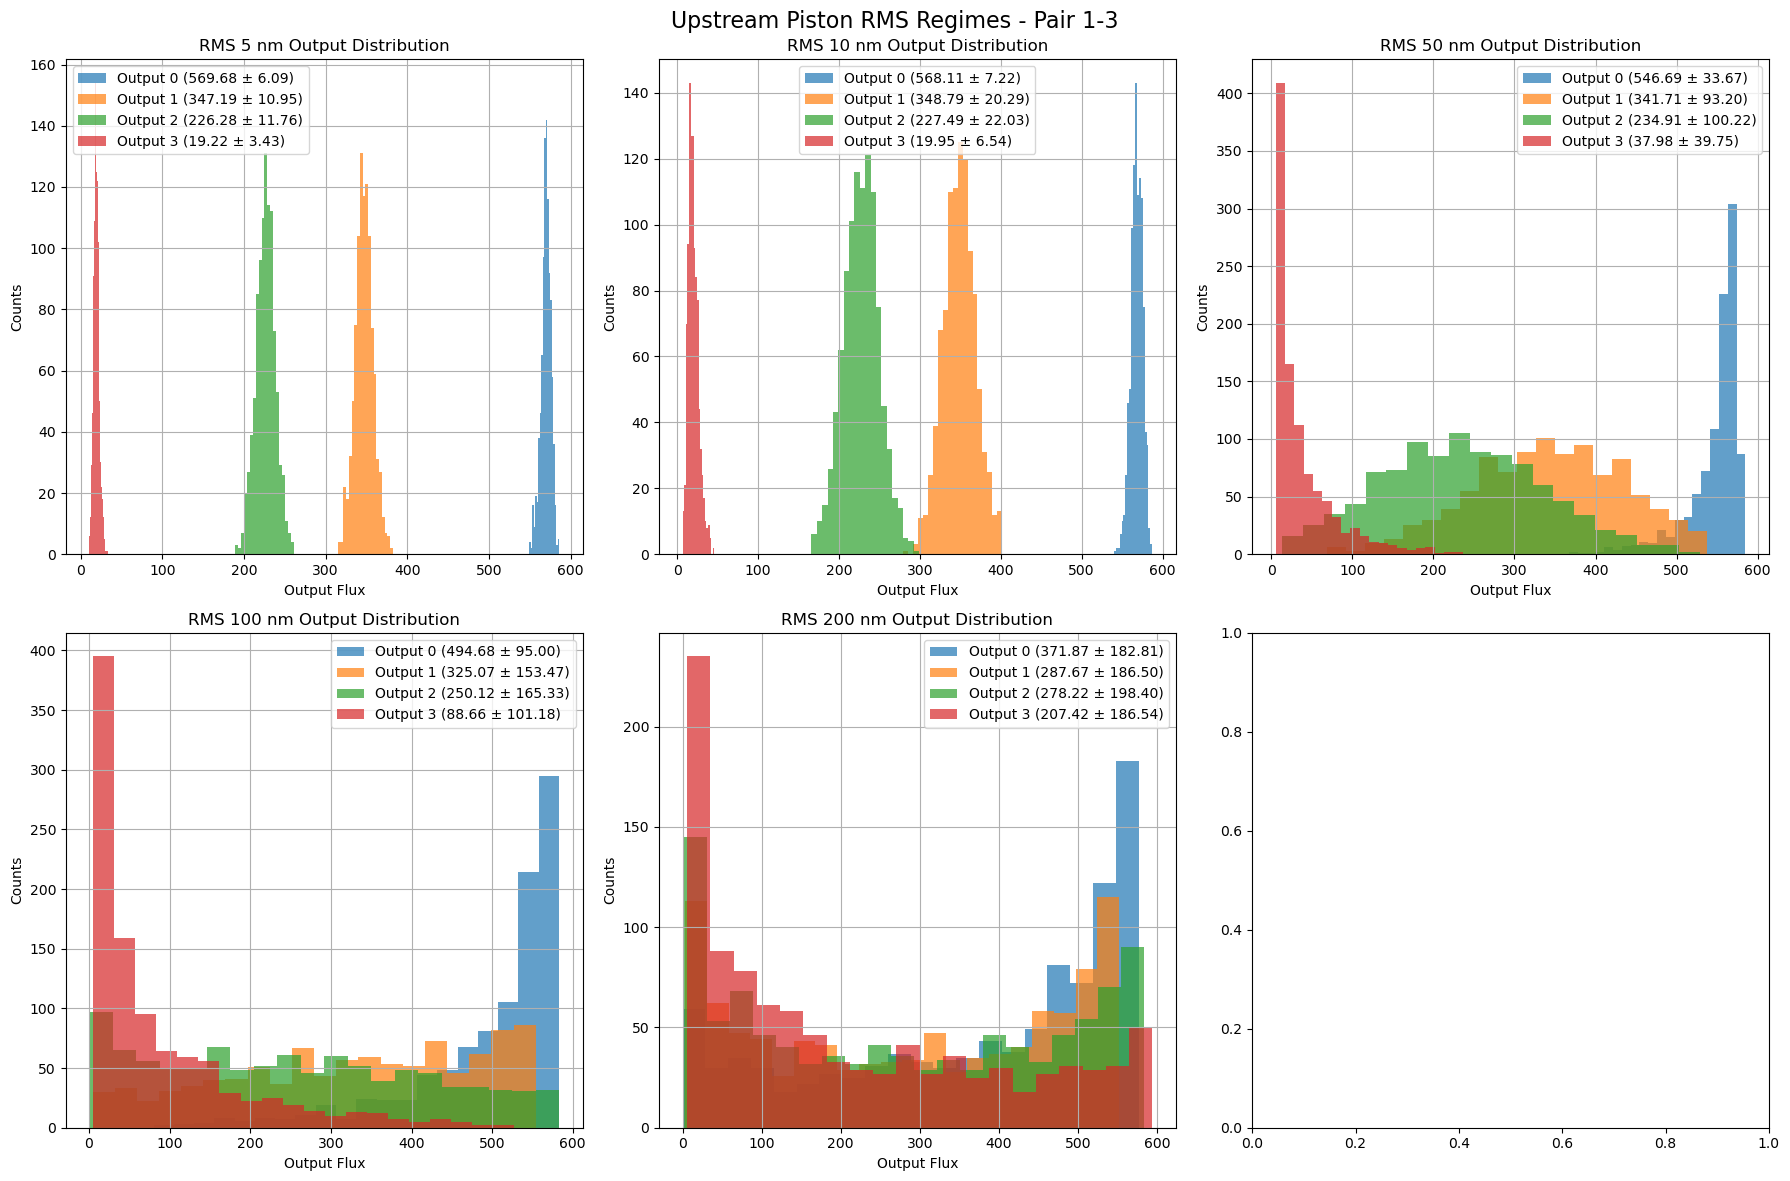

In [16]:
pair = (1, 3)
rms_values = [5, 10, 50, 100, 200] # [nm]
res_rms = rms_scan(1000, rms_values[:], lam, pair, False, True)

filename = 'fig_rms_pair_%s-%s.png'%(pair[0], pair[1])
try:
    res_rms['figure'].savefig(path / filename)
except:
    pass


In [17]:
filename = 'res_rms_pair_%s-%s.pkl'%(pair[0], pair[1])
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms, f)

# Same with TOPA correction

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=5 nm...


100%|██████████| 1000/1000 [02:40<00:00,  6.25it/s]


Scanning RMS=10 nm...


100%|██████████| 1000/1000 [02:40<00:00,  6.25it/s]


Scanning RMS=50 nm...


...

Scanning RMS=100 nm...


100%|██████████| 1000/1000 [02:39<00:00,  6.25it/s]


Scanning RMS=200 nm...


100%|██████████| 1000/1000 [02:39<00:00,  6.25it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


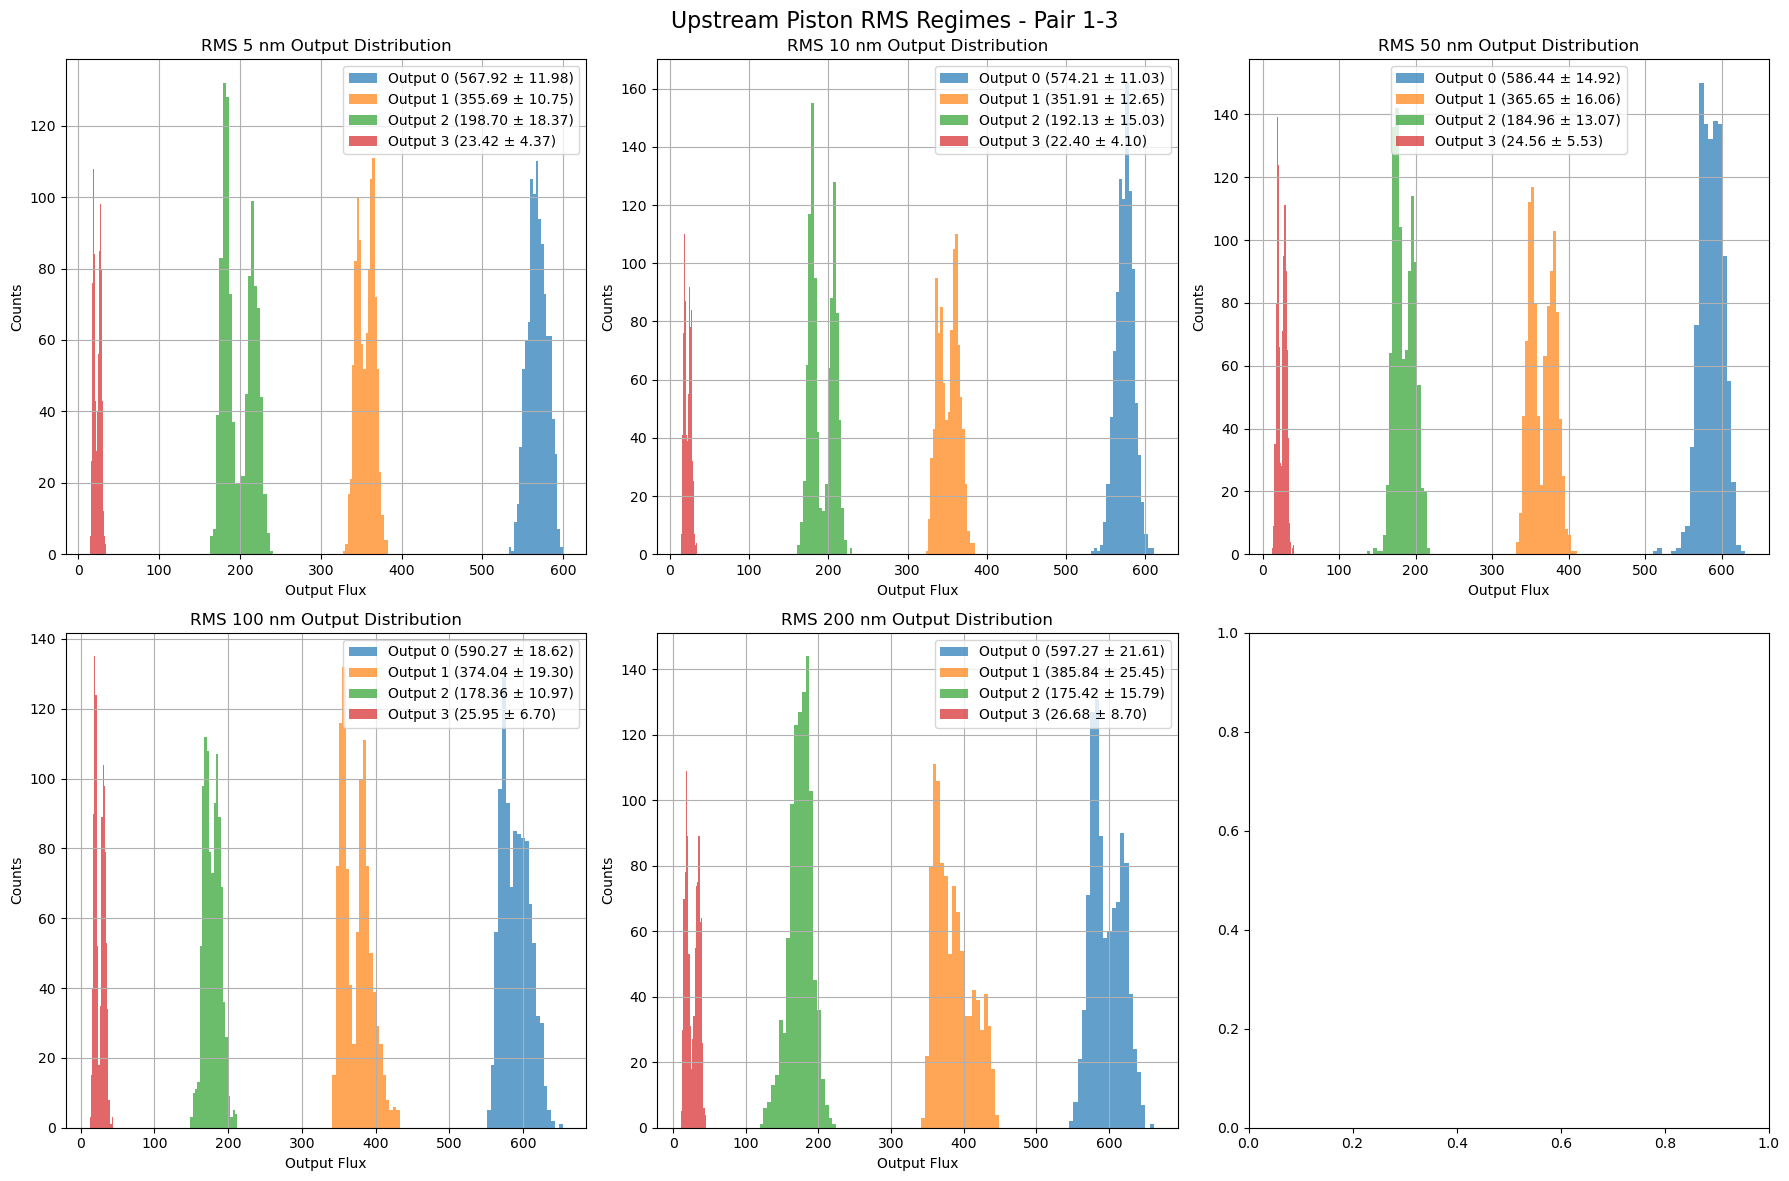

In [18]:
res_rms_corrected = rms_scan(1000, rms_values[:], lam, pair, True, True)
filename = 'fig_rms_corrected_pair_%s-%s.png'%(pair[0], pair[1])
res_rms_corrected['figure'].savefig(path / filename)

In [19]:
filename = 'res_rms_corrected_pair_%s-%s.pkl'%(pair[0], pair[1])
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms_corrected, f)

# Same with the other pairs

## No TOPAS

In [ ]:
# pairs = [(0,1), (0,2), (0,3), (1,2), (2,3)]

# for pair in pairs:
#     res_rms = rms_scan(1000, rms_values[:], lam, pair, False, True)

#     filename = 'fig_rms_pair_%s-%s.png'%(pair[0], pair[1])
#     try:
#         res_rms['figure'].savefig(path / filename)
#     except:
#         pass

#     filename = 'res_rms_pair_%s-%s.pkl'%(pair[0], pair[1])
#     with open(path / filename, 'wb') as f:
#         pickle.dump(res_rms, f)

## With TOPAS

In [ ]:
# pairs = [(0,1), (0,2), (0,3), (1,2), (2,3)]

# for pair in pairs:
#     res_rms_corrected = rms_scan(1000, rms_values[:], lam, pair, True, True)
#     filename = 'fig_rms_corrected_pair_%s-%s.png'%(pair[0], pair[1])

#     try:
#         res_rms_corrected['figure'].savefig(path / filename)
#     except:
#         pass

#     filename = 'res_rms_corrected_pair_%s-%s.pkl'%(pair[0], pair[1])
#     with open(path / filename, 'wb') as f:
#         pickle.dump(res_rms_corrected, f)

# The end

In [20]:
phobos.XPOW().turn_off()
inj.zero()

Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
